# Prey and Predator 2D variation

Homework 2 - Particle Methods, Spring 2026;
Ferdinando Giordano.

In [5]:
# Initialization Cell 
# Imports 
import random, math
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np

# Constants
L = 10.0;  Nr = 900;  Nw = 100;  SIGMA = 0.5
RABBIT_REP_PROB = 0.02;  RABBIT_DEATH_AGE = 100
WOLF_EAT_PROB   = 0.02;  WOLF_REP_PROB = 0.02
RC = 0.5;  WOLF_STARVE_TIME = 50;  SEED = 42

# Classes 

@dataclass
class Rabbit:
    x: float
    y: float
    age: int = 0

@dataclass
class Wolf:
    x: float
    y: float
    age: int = 0
    time_since_eaten: int = 0

# initialization

rng = random.Random(SEED)
pos = lambda: (rng.uniform(0, L), rng.uniform(0, L))

rabbits = [Rabbit(*pos(), rng.randint(1, RABBIT_DEATH_AGE-1)) for _ in range(Nr)]
wolves  = [Wolf(*pos()) for _ in range(Nw)]

state = {"t": 0, "rabbits": rabbits, "wolves": wolves,
         "rabbit_counts": [Nr], "wolf_counts": [Nw], "rng": rng}

In [7]:
# Validation and Test 

# Validation 
assert len(rabbits) == Nr and len(wolves) == Nw
assert all(0 <= r.x < L and 0 <= r.y < L and 1 <= r.age < RABBIT_DEATH_AGE for r in rabbits)
assert all(0 <= w.x < L and 0 <= w.y < L and w.time_since_eaten == 0 for w in wolves)

# Test

ages = [r.age for r in rabbits]
print(f"Rabbits: {len(rabbits)}  |  Wolves: {len(wolves)}")
print(f"Rabbit ages min: {min(ages)}  max: {max(ages)}  mean: {sum(ages)/len(ages):.1f}")
print(f"Sample rabbit: {rabbits[0]}")
print(f"Sample wolf:   {wolves[0]}")


Rabbits: 900  |  Wolves: 100
Rabbit ages min: 1  max: 99  mean: 50.9
Sample rabbit: Rabbit(x=6.394267984578837, y=0.25010755222666936, age=36)
Sample wolf:   Wolf(x=2.3185554741141035, y=4.050474362802529, age=0, time_since_eaten=0)


In [15]:
# 1 simulation step

def pbc_dist(x1, y1, x2, y2):
    dx = min(abs(x1-x2), L - abs(x1-x2))
    dy = min(abs(y1-y2), L - abs(y1-y2))
    return math.hypot(dx, dy)

def move(agent, rng):
    theta = rng.uniform(0, 2*math.pi)
    dr    = rng.gauss(0, SIGMA)
    agent.x = (agent.x + dr*math.cos(theta)) % L
    agent.y = (agent.y + dr*math.sin(theta)) % L

def wolf_eats(w, rabbits, rng):
    eaten = [i for i in range(len(rabbits)-1, -1, -1)
             if pbc_dist(w.x, w.y, rabbits[i].x, rabbits[i].y) < RC
             and rng.random() < WOLF_EAT_PROB]
    for i in eaten:
        rabbits.pop(i)
    return len(eaten)

def simulation_step(state):
    rng     = state["rng"]
    rabbits = state["rabbits"]
    wolves  = state["wolves"]

    # 1. Move
    for agent in rabbits + wolves:
        move(agent, rng)

    # 2. Wolves hunt
    new_wolves = []
    for w in wolves:
        w.time_since_eaten += 1
        n_eaten = wolf_eats(w, rabbits, rng)
        if n_eaten:
            w.time_since_eaten = 0
            for _ in range(n_eaten):
                if rng.random() < WOLF_REP_PROB:
                    new_wolves.append(Wolf(w.x, w.y))

    # 3. Rabbits age & reproduce
    new_rabbits = []
    for r in rabbits:
        r.age += 1
        if rng.random() < RABBIT_REP_PROB:
            new_rabbits.append(Rabbit(r.x, r.y, 0))

    # 4. Apply deaths & births
    state["rabbits"] = [r for r in rabbits if r.age < RABBIT_DEATH_AGE] + new_rabbits
    state["wolves"]  = [w for w in wolves if w.time_since_eaten < WOLF_STARVE_TIME] + new_wolves
    state["t"] += 1
    state["rabbit_counts"].append(len(state["rabbits"]))
    state["wolf_counts"].append(len(state["wolves"]))

simulation_step(state)
print(state["t"], len(state["rabbits"]), len(state["wolves"]))

1 886 100


In [20]:
# let's try with 10 steps
for _ in range(10):
    simulation_step(state)
    print(state["t"], len(state["rabbits"]), len(state["wolves"]))

31 757 106
32 752 106
33 752 106
34 753 106
35 762 106
36 764 106
37 768 106
38 774 106
39 765 108
40 763 109


Simulation works fine for 10 steps, as the simulations are stochastic the count is okay to not be (1-10), If we ran the 1st simulation from scratch we would have them.  

### Part a)

Initialize the system with random distribution of rabbits and wolves in the domain. Set step size
parameter σ equal to 0.5 both for rabbits and wolves. Assume rabbits die at the age of tr
d = 100
time steps. Run simulations and look at the evolution of the number of rabbits and wolves in time.
You may want to run simulations for few thousand steps(i) Consider the Lotka-Volterra equations
(https://en.wikipedia.org/wiki/Lotka-Volterra equations). Our model does not exactly corresponds to
these equations, nevertheless what are the similarities between your simulations and solution of these
equations? (ii)

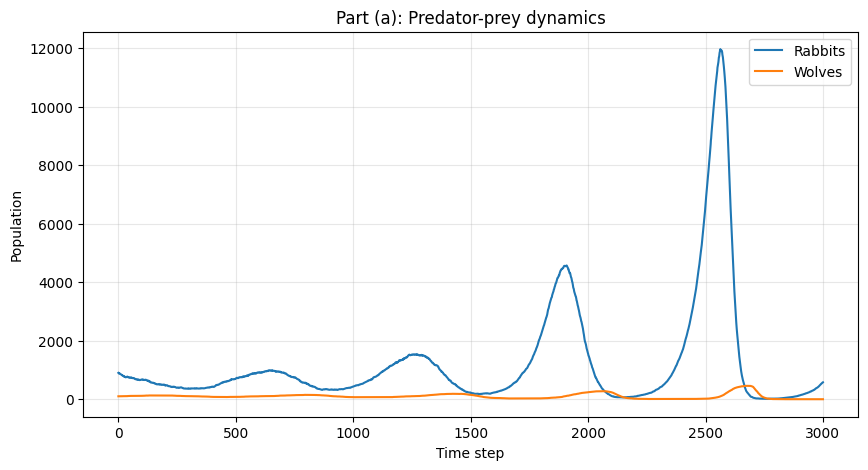

Final time: 3000
Final rabbits: 578
Final wolves: 0


In [21]:
# Part (a): run simulation and plot populations

# fresh initialization
rng = random.Random(SEED)
pos = lambda: (rng.uniform(0, L), rng.uniform(0, L))

rabbits = [Rabbit(*pos(), rng.randint(1, RABBIT_DEATH_AGE - 1)) for _ in range(Nr)]
wolves  = [Wolf(*pos()) for _ in range(Nw)]

state = {
    "t": 0,
    "rabbits": rabbits,
    "wolves": wolves,
    "rabbit_counts": [Nr],
    "wolf_counts": [Nw],
    "rng": rng
}

# run for a few thousand steps
n_steps = 3000
for _ in range(n_steps):
    simulation_step(state)

# plot
plt.figure(figsize=(10, 5))
plt.plot(state["rabbit_counts"], label="Rabbits")
plt.plot(state["wolf_counts"], label="Wolves")
plt.xlabel("Time step")
plt.ylabel("Population")
plt.title("Part (a): Predator-prey dynamics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Final time:", state["t"])
print("Final rabbits:", len(state["rabbits"]))
print("Final wolves:", len(state["wolves"]))

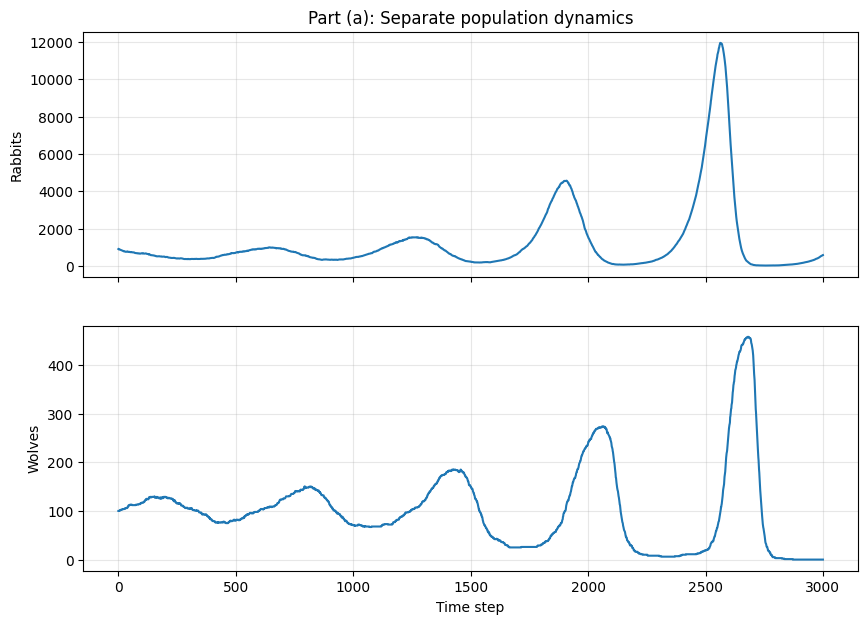

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(10,7), sharex=True)

ax[0].plot(state["rabbit_counts"])
ax[0].set_ylabel("Rabbits")
ax[0].set_title("Part (a): Separate population dynamics")
ax[0].grid(True, alpha=0.3)

ax[1].plot(state["wolf_counts"])
ax[1].set_xlabel("Time step")
ax[1].set_ylabel("Wolves")
ax[1].grid(True, alpha=0.3)

plt.show()

The plot shows a typical predator–prey cycle where rabbits grow first, wolves increase after a delay, and then both populations decline. The behavior is qualitatively similar to Lotka–Volterra, but less regular because the simulation includes randomness and local interactions.

### Part b)

Repeat simulations with the same parameters as in case a), but now set the age for each rabbit to die
to tr
d = 50 time steps. Try to run couple of cases with different random number generator seeds. What
kind of results do you get and why?

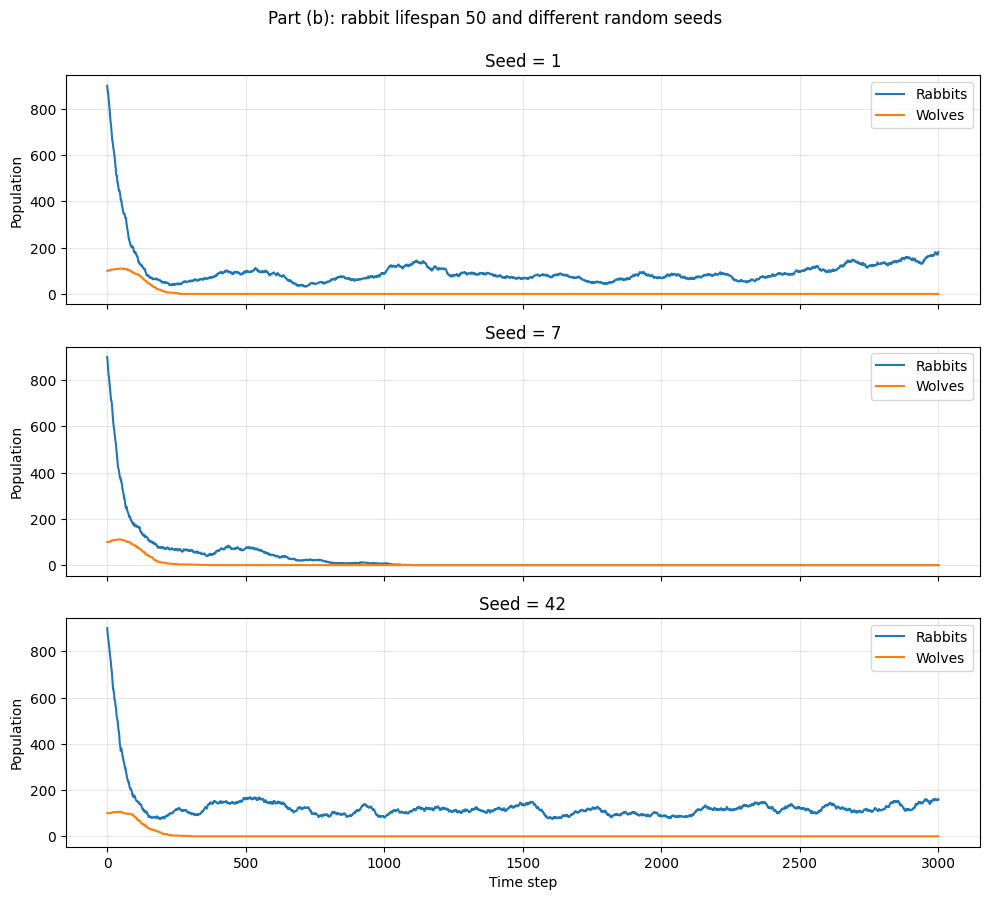

In [ ]:
RABBIT_DEATH_AGE = 50
seeds = [1, 7, 42]

fig, axes = plt.subplots(len(seeds), 1, figsize=(10, 9), sharex=True)

for ax, seed in zip(axes, seeds):
    rng = random.Random(seed)
    pos = lambda: (rng.uniform(0, L), rng.uniform(0, L))

    rabbits = [Rabbit(*pos(), rng.randint(1, RABBIT_DEATH_AGE - 1)) for _ in range(Nr)]
    wolves  = [Wolf(*pos()) for _ in range(Nw)]

    state = {
        "t": 0,
        "rabbits": rabbits,
        "wolves": wolves,
        "rabbit_counts": [Nr],
        "wolf_counts": [Nw],
        "rng": rng
    }

    for _ in range(3000):
        simulation_step(state)

    ax.plot(state["rabbit_counts"], label="Rabbits")
    ax.plot(state["wolf_counts"], label="Wolves")
    ax.set_title(f"Seed = {seed}")
    ax.set_ylabel("Population")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Time step")
fig.suptitle("Part (b): Rabbit lifespan 50 and different random seeds", y=0.995)
plt.tight_layout()
plt.show()

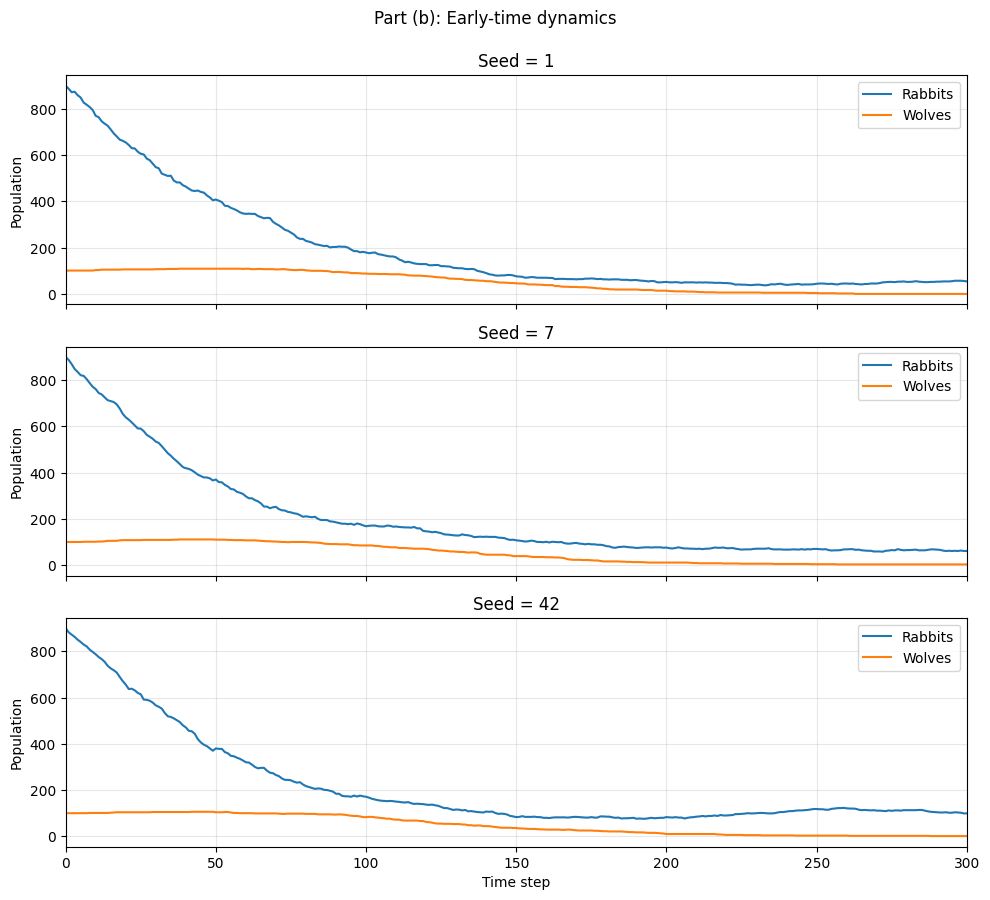

In [26]:
fig, axes = plt.subplots(len(seeds), 1, figsize=(10, 9), sharex=True)

for ax, seed in zip(axes, seeds):
    rng = random.Random(seed)
    pos = lambda: (rng.uniform(0, L), rng.uniform(0, L))

    rabbits = [Rabbit(*pos(), rng.randint(1, RABBIT_DEATH_AGE - 1)) for _ in range(Nr)]
    wolves  = [Wolf(*pos()) for _ in range(Nw)]

    state = {
        "t": 0,
        "rabbits": rabbits,
        "wolves": wolves,
        "rabbit_counts": [Nr],
        "wolf_counts": [Nw],
        "rng": rng
    }

    for _ in range(3000):
        simulation_step(state)

    ax.plot(state["rabbit_counts"], label="Rabbits")
    ax.plot(state["wolf_counts"], label="Wolves")
    ax.set_xlim(0, 300)   # zoom on early dynamics
    ax.set_title(f"Seed = {seed}")
    ax.set_ylabel("Population")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Time step")
fig.suptitle("Part (b): Early-time dynamics", y=0.995)
plt.tight_layout()
plt.show()

Reducing rabbit lifetime to  50 makes the system more fragile in fact  wolves tend to die out quickly, while rabbits recover differently depending on the random seed.

### Part c) 

Repeat simulations with the same parameters as in case a), but now set step size parameter σ equal
to 0.05 both for rabbits and wolves. Again, run simulations for few thousand steps. If your simulations
take too long, you can reduce the size of the domain to L= 8 units. Look at the dynamics of agents in
the domain, is it different from case a)? Do you think something like Lotka-Volterra equations can be a
good approximation? What makes the difference in this case?

Compared with part a), reducing 𝜎 makes the dynamics more local in space, since wolves and rabbits explore the domain more slowly and interact less efficiently.

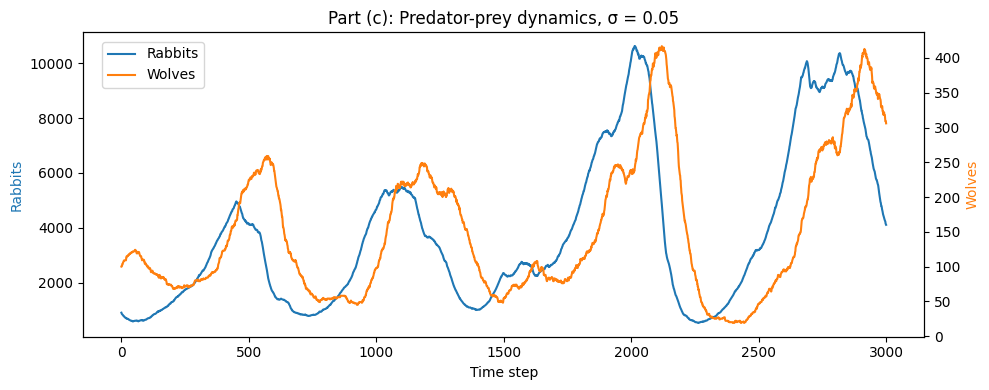

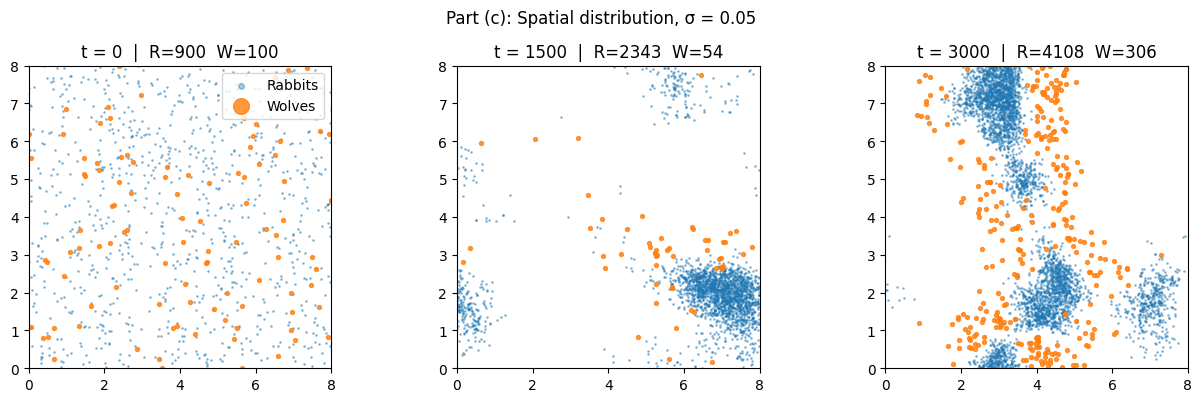

In [34]:
# Part c): sigma = 0.05
SIGMA = 0.05
RABBIT_DEATH_AGE = 100
L = 8

rng = random.Random(SEED)
pos = lambda: (rng.uniform(0, L), rng.uniform(0, L))

rabbits = [Rabbit(*pos(), rng.randint(1, RABBIT_DEATH_AGE - 1)) for _ in range(Nr)]
wolves  = [Wolf(*pos()) for _ in range(Nw)]

state = {
    "t": 0, "rabbits": rabbits, "wolves": wolves,
    "rabbit_counts": [Nr], "wolf_counts": [Nw], "rng": rng
}

snapshot_steps = [0, 1500, 3000]
snapshots = {}

for step_i in range(3000):
    if step_i in snapshot_steps:
        snapshots[step_i] = (
            [(r.x, r.y) for r in state["rabbits"]],
            [(w.x, w.y) for w in state["wolves"]]
        )
    simulation_step(state)

snapshots[3000] = (
    [(r.x, r.y) for r in state["rabbits"]],
    [(w.x, w.y) for w in state["wolves"]]
)

# Plot 1: dual-axis population dynamics
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(state["rabbit_counts"], color="tab:blue", label="Rabbits")
ax2.plot(state["wolf_counts"],   color="tab:orange", label="Wolves")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Rabbits", color="tab:blue")
ax2.set_ylabel("Wolves",  color="tab:orange")
ax1.set_title("Part (c): Predator-prey dynamics, σ = 0.05")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

# Plot 2: spatial snapshots
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, t in zip(axes, snapshot_steps):
    r_pos = snapshots[t][0]
    w_pos = snapshots[t][1]
    if r_pos:
        rx, ry = zip(*r_pos)
        ax.scatter(rx, ry, s=1, color="tab:blue", alpha=0.4, label="Rabbits")
    if w_pos:
        wx, wy = zip(*w_pos)
        ax.scatter(wx, wy, s=8, color="tab:orange", alpha=0.8, label="Wolves")
    ax.set_xlim(0, L); ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.set_title(f"t = {t}  |  R={len(r_pos)}  W={len(w_pos)}")

axes[0].legend(loc="upper right", markerscale=4)
fig.suptitle("Part (c): Spatial distribution, σ = 0.05")
plt.tight_layout()
plt.show()

sigma=0.05 causes slow mixing, agents cluster spatially and rabbits grow unchecked in predator-free zones producing large irregular oscillations